In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
ruta = 'https://github.com/jamc88/AD-MCMAI/raw/refs/heads/main/Datos/incidencia_delictiva_2015-2025.csv'

df = pd.read_csv(ruta)
df

,Año,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4,0,3,4,6,1,1.0,2.0,5.0,1.0,2.0,3.0
1,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,0,0,0,0,3,0.0,0.0,0.0,0.0,0.0,1.0
2,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,2,1,1,0,1,0,2.0,0.0,1.0,0.0,0.0,0.0
3,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18321,2025,9998,No Especificado,Otros bienes jurídicos afectados (del fuero co...,Falsificación,Falsificación,Falsificación,3,4,4,3,2,6,NaN,NaN,NaN,NaN,NaN,NaN
18322,2025,9998,No Especificado,Otros bienes jurídicos afectados (del fuero co...,Contra el medio ambiente,Contra el medio ambiente,Contra el medio ambiente,0,0,2,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
18323,2025,9998,No Especificado,Otros bienes jurídicos afectados (del fuero co...,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,73,106,104,100,39,23,NaN,NaN,NaN,NaN,NaN,NaN
18324,2025,9998,No Especificado,Otros bienes jurídicos afectados (del fuero co...,Electorales,Electorales,Electorales,0,0,1,1,2,6,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18326 entries, 0 to 18325
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     18326 non-null  int64  
 1   Cve. Municipio          18326 non-null  int64  
 2   Municipio               18326 non-null  object 
 3   Bien jurídico afectado  18326 non-null  object 
 4   Tipo de delito          18326 non-null  object 
 5   Subtipo de delito       18326 non-null  object 
 6   Modalidad               18326 non-null  object 
 7   Enero                   18326 non-null  int64  
 8   Febrero                 18326 non-null  int64  
 9   Marzo                   18326 non-null  int64  
 10  Abril                   18326 non-null  int64  
 11  Mayo                    18326 non-null  int64  
 12  Junio                   18326 non-null  int64  
 13  Julio                   16660 non-null  float64
 14  Agosto                  16660 non-null

In [4]:
df = df.fillna(0)

In [5]:
df['Julio'] = df['Julio'].astype('int64')
df['Agosto'] = df['Agosto'].astype('int64')
df['Septiembre'] = df['Septiembre'].astype('int64')
df['Octubre'] = df['Octubre'].astype('int64')
df['Noviembre'] = df['Noviembre'].astype('int64')
df['Diciembre'] = df['Diciembre'].astype('int64')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18326 entries, 0 to 18325
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Año                     18326 non-null  int64 
 1   Cve. Municipio          18326 non-null  int64 
 2   Municipio               18326 non-null  object
 3   Bien jurídico afectado  18326 non-null  object
 4   Tipo de delito          18326 non-null  object
 5   Subtipo de delito       18326 non-null  object
 6   Modalidad               18326 non-null  object
 7   Enero                   18326 non-null  int64 
 8   Febrero                 18326 non-null  int64 
 9   Marzo                   18326 non-null  int64 
 10  Abril                   18326 non-null  int64 
 11  Mayo                    18326 non-null  int64 
 12  Junio                   18326 non-null  int64 
 13  Julio                   18326 non-null  int64 
 14  Agosto                  18326 non-null  int64 
 15  Se

In [7]:
df.columns

Index(['Año', 'Cve. Municipio', 'Municipio', 'Bien jurídico afectado',
       'Tipo de delito', 'Subtipo de delito', 'Modalidad', 'Enero', 'Febrero',
       'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre',
       'Octubre', 'Noviembre', 'Diciembre'],
      dtype='object')

In [8]:
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

df_largo = (
    df
    .melt(
        id_vars=['Año','Cve. Municipio','Municipio',
                 'Bien jurídico afectado','Tipo de delito',
                 'Subtipo de delito','Modalidad'],
        value_vars=meses,
        var_name='Mes',
        value_name='Casos'
    )
    .assign(
        Mes_num = lambda d: d['Mes'].map({
            'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
            'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,
            'Noviembre':11,'Diciembre':12
        }),
        Fecha = lambda d: pd.to_datetime(dict(year=d['Año'], month=d['Mes_num'], day=1))
    )
    .sort_values(['Municipio','Fecha'])
    .reset_index(drop=True)
)

In [9]:
df_largo.head()

,Año,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Mes,Casos,Mes_num,Fecha
0,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Enero,4,1,2015-01-01
1,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Enero,1,1,2015-01-01
2,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Enero,2,1,2015-01-01
3,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Enero,0,1,2015-01-01
4,2015,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Enero,0,1,2015-01-01


In [10]:
df=df_largo[['Fecha', 'Año', 'Mes_num', 'Mes', 'Cve. Municipio', 'Municipio', 'Bien jurídico afectado',
       'Tipo de delito', 'Subtipo de delito', 'Modalidad',  'Casos']]
df.head()

,Fecha,Año,Mes_num,Mes,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Casos
0,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4
1,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1
2,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,2
3,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0
4,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0


/var/folders/16/rwkptmp92_b7tw7nx11rkvbw0000gn/T/ipykernel_3514/3053028105.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data=df, x='Fecha', y='Casos', hue='Municipio',


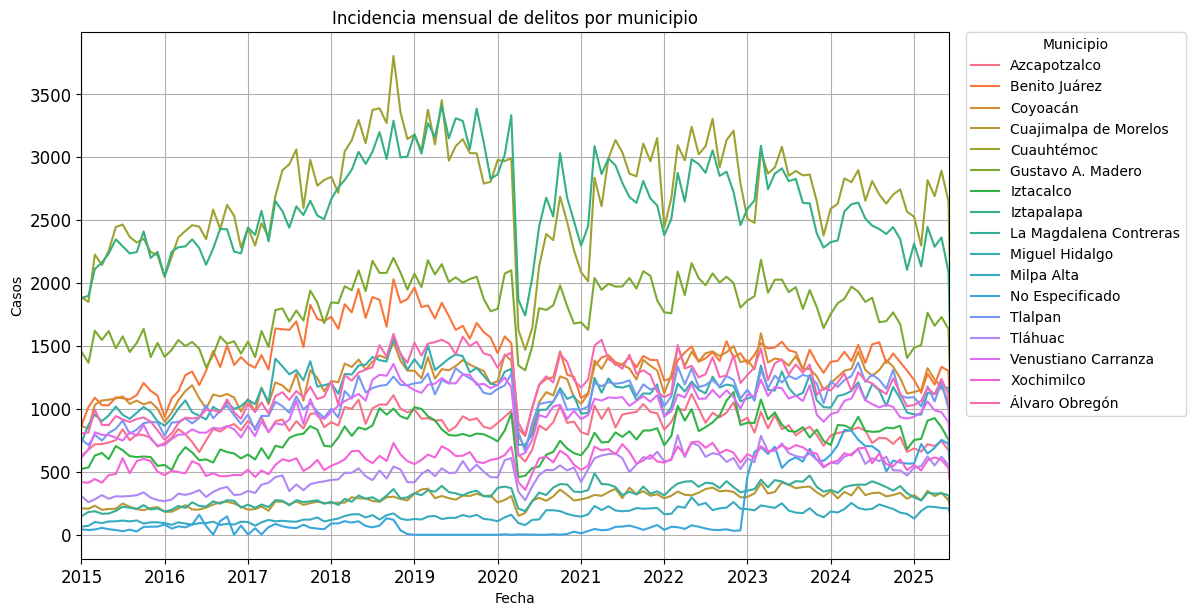

In [12]:
# Tendencia mensual por municipio
plt.figure(figsize=(12,6))
ax = sns.lineplot(data=df, x='Fecha', y='Casos', hue='Municipio',
                  estimator='sum', ci=None, legend='full')

ax.legend(title='Municipio', bbox_to_anchor=(1.02, 1), 
    loc='upper left', borderaxespad=0)

ax.set_xlim(
    pd.Timestamp('2015-01-01'),
    pd.Timestamp('2025-06-01')
)

plt.tight_layout()
plt.grid(True)
plt.tick_params(labelsize=12)
plt.title("Incidencia mensual de delitos por municipio")
plt.show()


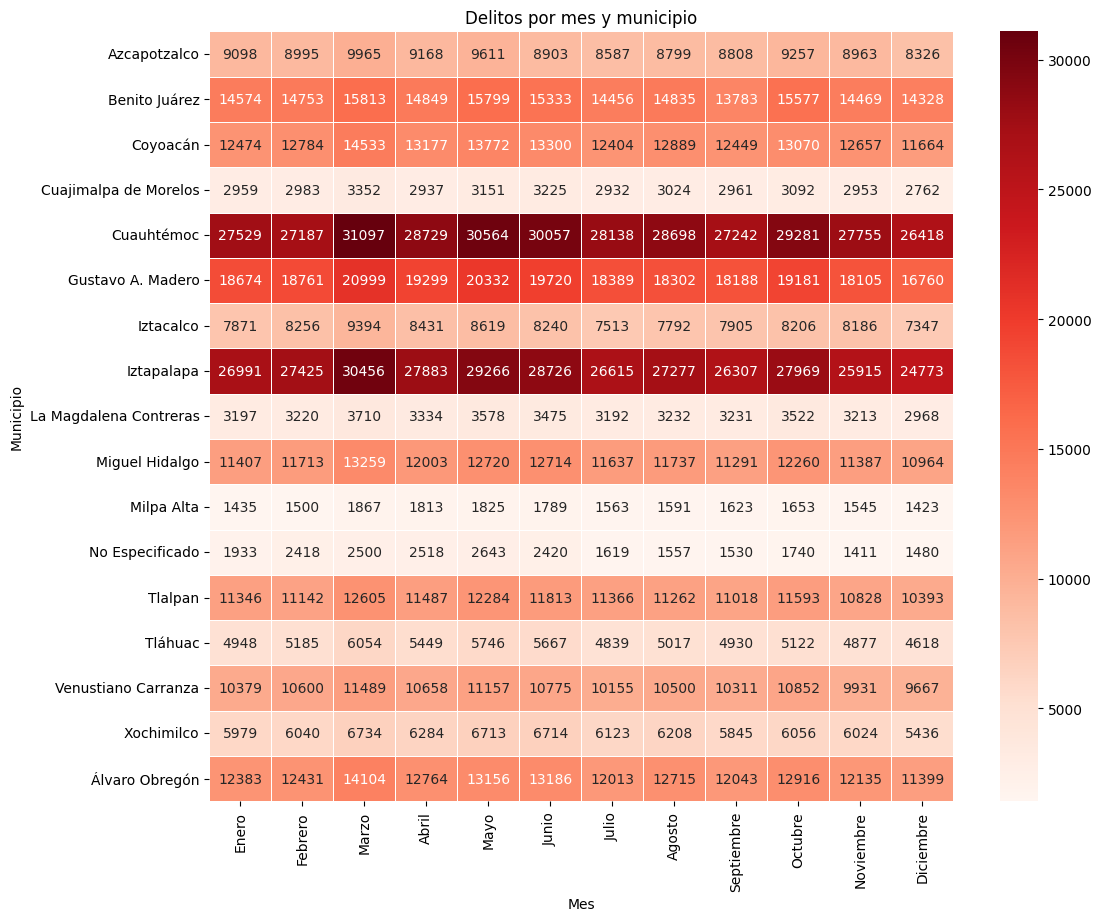

In [13]:
# Heatmap anual-mensual
# sumamos todos los casos por mes de cada año
pivot = df.pivot_table(
    index='Municipio', columns='Mes', values='Casos', aggfunc='sum'
)
pivot = pivot[['Enero', 'Febrero', 'Marzo','Abril', 'Mayo','Junio', 'Julio', 
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre','Diciembre']]
plt.figure(figsize=(12,10))
sns.heatmap(pivot, cmap='Reds', linewidths=0.5, annot=True, fmt=".0f")
plt.title("Delitos por mes y municipio")
plt.show()

In [43]:
df_cd = (df.groupby('Fecha')['Casos'].sum().reset_index().set_index('Fecha').asfreq('MS'))
df_cd = df_cd['2015-01':'2025-06']
df_cd

,Casos
Fecha,
2015-01-01,12202
2015-02-01,12433
2015-03-01,14271
2015-04-01,13882
2015-05-01,14250
...,...
2025-02-01,16163
2025-03-01,18552
2025-04-01,17690


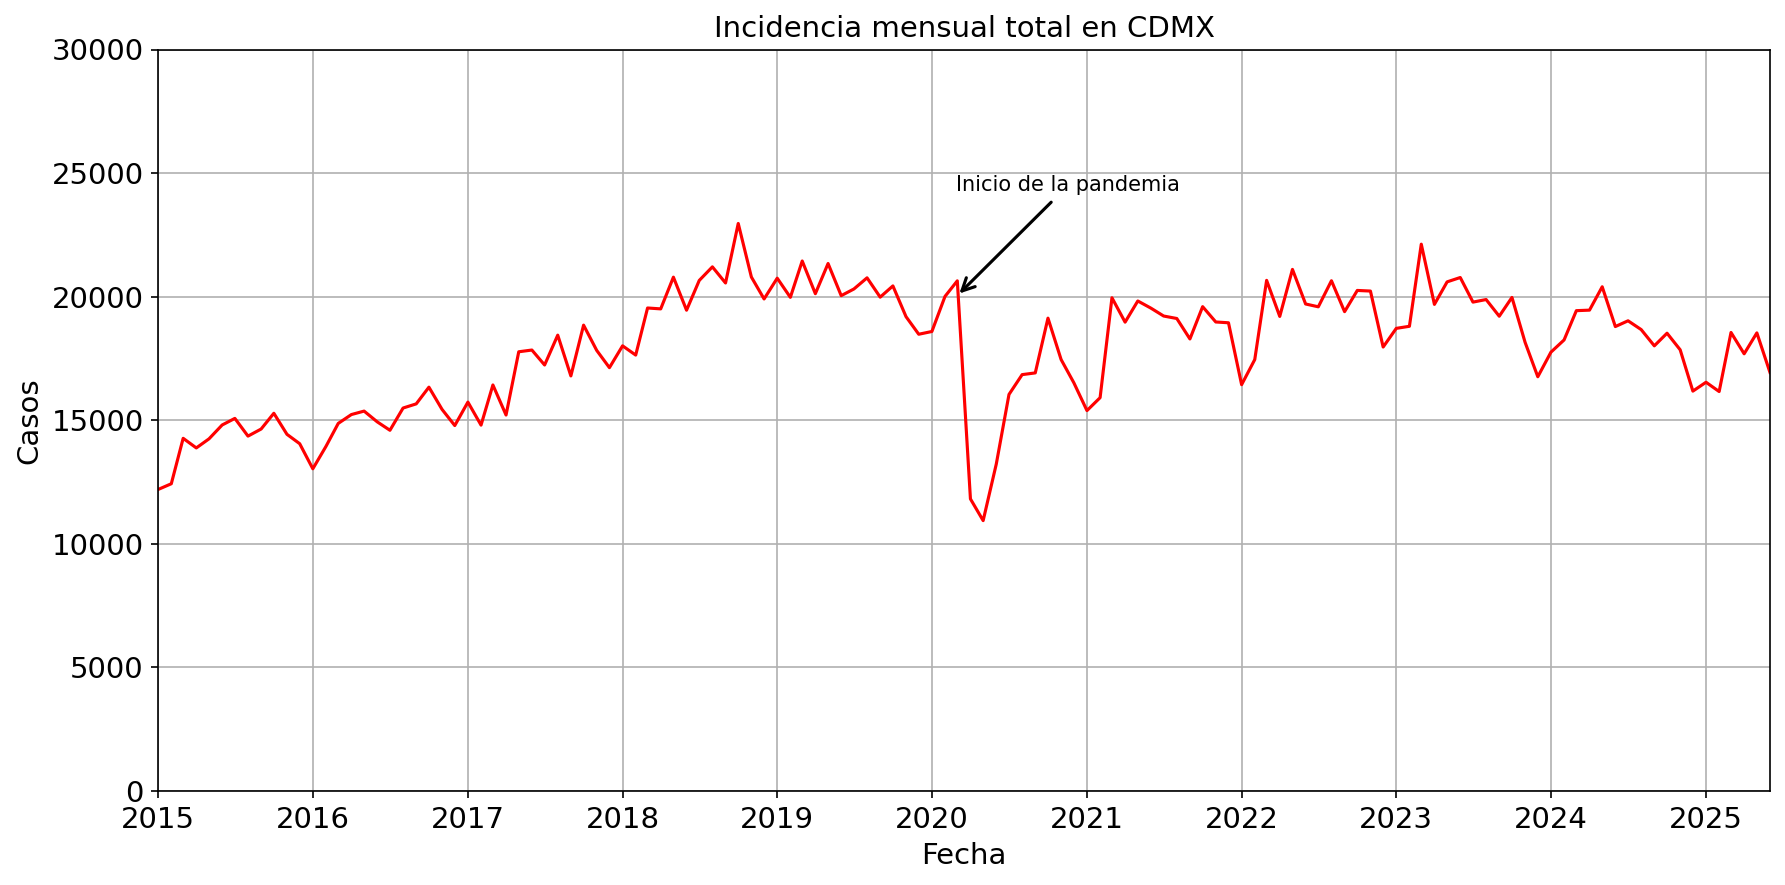

In [32]:
from datetime import datetime

casos_feb20 = df_cd.loc['2020-02-01', 'Casos']
punto_feb28 = pd.Timestamp('2020-02-28')

plt.figure(figsize=(12,6),dpi=150)
ax = sns.lineplot(data=df_cd, x=df_cd.index, y='Casos', legend=False, color = 'red')

ax.annotate('Inicio de la pandemia',
    xy=(punto_feb28, casos_feb20),                           
    xytext=(punto_feb28, df_cd['Casos'].max() * 1.05),        
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        color='black',
        mutation_scale=15),
    ha='left',
    va='bottom')

ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2025-06-01'))
ax.set_ylim(0,30_000)
plt.title("Incidencia mensual total en CDMX",fontsize=14)
plt.xlabel("Fecha",fontsize=14)
plt.ylabel("Casos",fontsize=14)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

### Descomposición STL

Para una descomposición STL adecuada a un ciclo anual, lo más común es:

period=12 (12 observaciones por año)

seasonal (ventana de estacionalidad): un número impar algo mayor que period, por ejemplo seasonal=13

trend (ventana de tendencia): controla la suavidad de la tendencia; un valor impar alrededor de 2×period, p. ej. trend=25

low_pass (baja frecuencia): puede dejarse igual a seasonal o usar low_pass=period

robust=True si hay picos muy atípicos (como el bache de 2020)

In [47]:
# Descomposición STL
from statsmodels.tsa.seasonal import STL

stl = STL(
    df_cd,
    period=12,        
    seasonal=13,      
    trend=25,         
    low_pass=13,      
    robust=True)

result = stl.fit()

df_stl = pd.DataFrame({
    'Tendencia': result.trend,
    'Estacionalidad': result.seasonal,
    'Residuo': result.resid
}, index=df_cd.index)

df_stl

,Tendencia,Estacionalidad,Residuo
Fecha,,,
2015-01-01,13685.536435,-1159.284061,-324.252374
2015-02-01,13766.692586,-1100.474118,-233.218468
2015-03-01,13846.918461,69.391056,354.690484
2015-04-01,13926.401491,62.990693,-107.392184
2015-05-01,14005.266153,446.949469,-202.215622
...,...,...,...
2025-02-01,17495.828260,-1161.038253,-171.790006
2025-03-01,17363.011382,1300.362654,-111.374036
2025-04-01,17228.582793,428.879260,32.537947


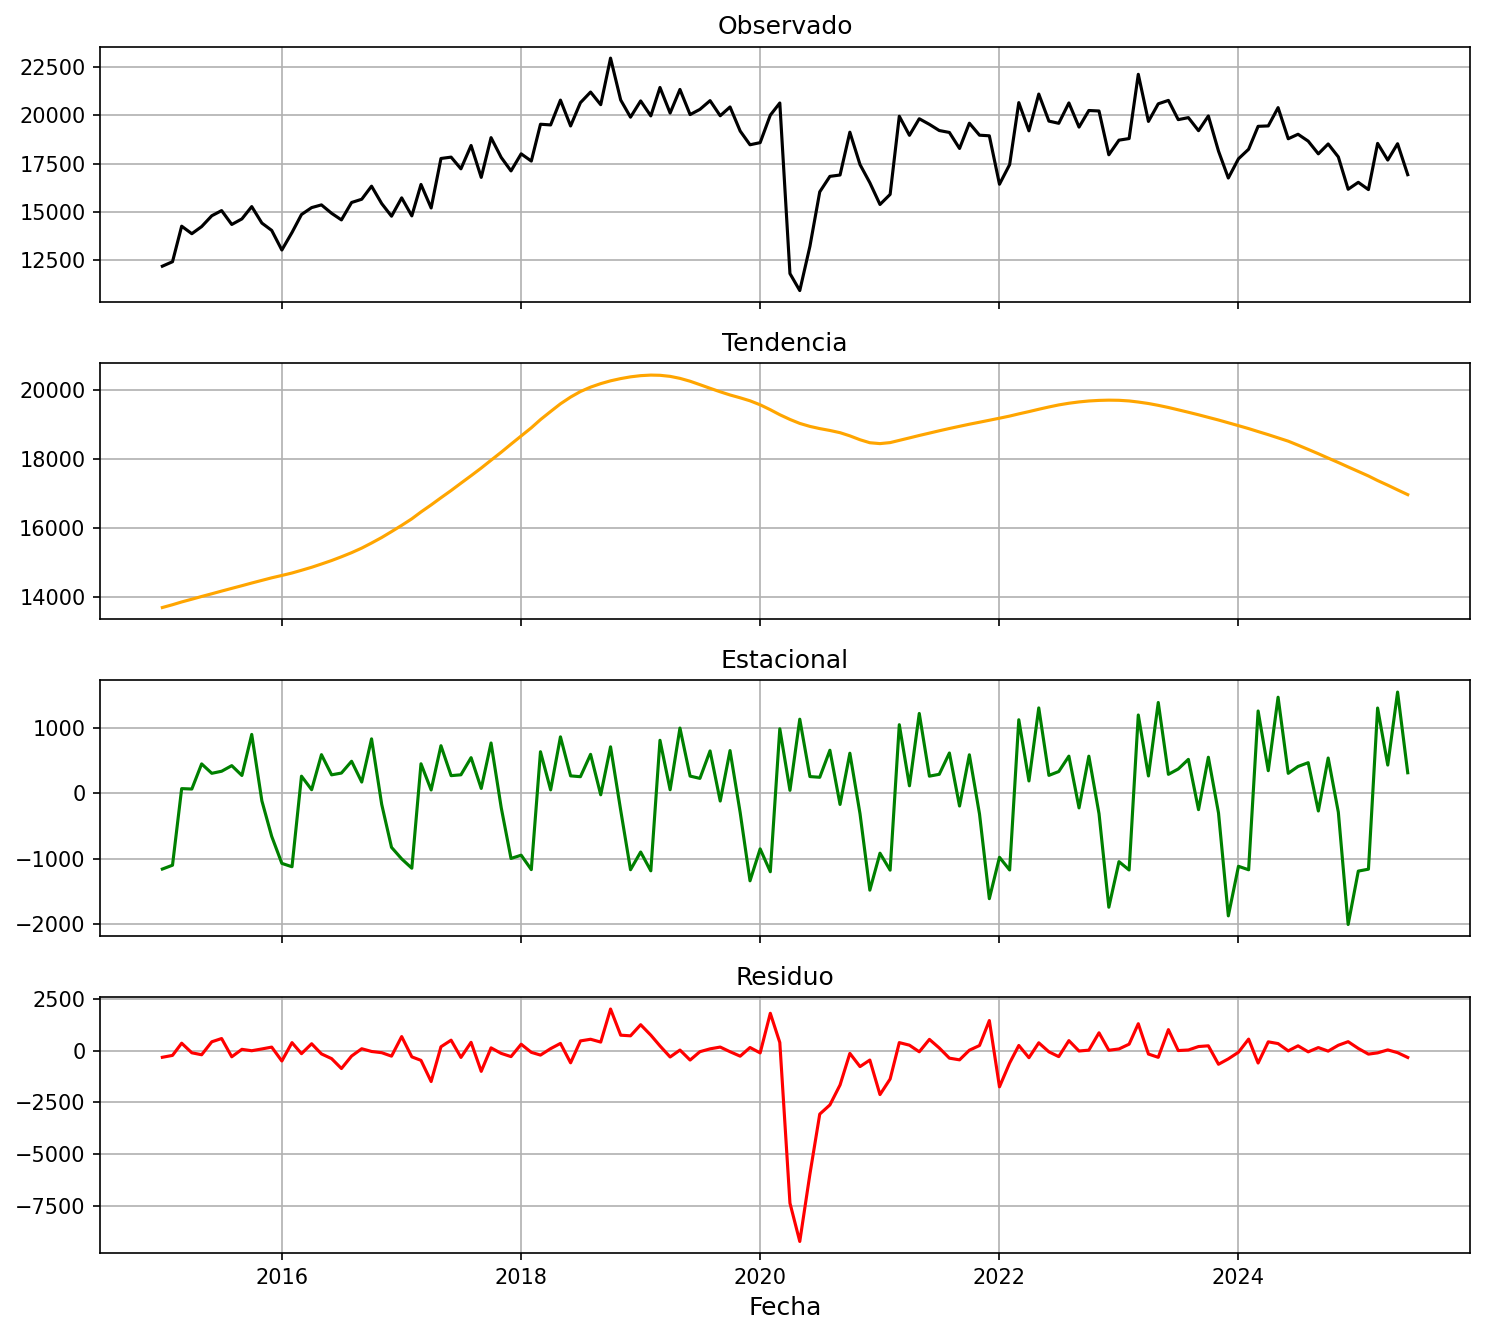

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True, dpi =150)

axes[0].plot(result.observed, label='Serie Temporal', color='black')
axes[0].set_title('Observado')
axes[0].tick_params(labelsize=10)
axes[0].grid()

axes[1].plot(df_stl['Tendencia'],   label='Tendencia', color='orange')
axes[1].set_title('Tendencia')
axes[1].tick_params(labelsize=10)
axes[1].grid()

axes[2].plot(df_stl['Estacionalidad'], label='Estacional', color='green')
axes[2].set_title('Estacional')
axes[2].tick_params(labelsize=10)
axes[2].grid()

axes[3].plot(result.resid,    label='Residuo', color='red')
axes[3].set_title('Residuo')
axes[3].set_xlabel('Fecha',fontsize=12)
axes[3].tick_params(labelsize=10)
axes[3].grid()

plt.tight_layout()
plt.show()


**Observado:** La serie original de casos mensuales:
- Un alza sostenida de 2015 hasta finales de 2019.
- Un desplome abrupto en marzo-2020 (confinamiento inicial).
- Un rebote gradual durante 2020–2021 y luego una meseta con ligeras oscilaciones entre 2022 y junio-2025.  

**Tendencia:** Suaviza la evolución a largo plazo usando una ventana amplia (≈2 años):
- Crecimiento claro hasta alcanzar un pico ≈20 000 casos/mes a finales de 2018–principios de 2019.
- Descenso pronunciado en marzo-2020, seguido de una recuperación modulada que llega a estabilizarse en ≈19 000 casos/mes en 2022.
- Desde 2023 hay una leve caída hacia ≈17 000 casos/mes en 2025.

**Estacional:** Captura el patrón repetitivo cada año (ventana estacional ≈13 meses):
- Se aprecian picos anuales (probablemente verano) de +1000 casos sobre la tendencia.
- Valles consistentes (meses fríos/iniciales de año) de –1000 a –1500 casos.
- La amplitud estacional se mantiene bastante estable año con año, incluso tras la pandemia.


**Residuo:** Muestra las fluctuaciones que no explica ni la tendencia ni la estacionalidad:
- Un gran residual negativo en marzo-2020 (~–8000), reflejo del shock sanitario.
- Varios picos y valles en 2020–2021 que corresponden a subidas o bajadas más allá de lo “esperado”.
- A partir de 2022 los residuos se concentran cerca de cero, indicando que el modelo STL (tendencia + estacional) explica bien la dinámica reciente.


In [51]:
df

,Fecha,Año,Mes_num,Mes,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Casos
0,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4
1,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1
2,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,2
3,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0
4,2015-01-01,2015,1,Enero,9002,Azcapotzalco,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0
...,...,...,...,...,...,...,...,...,...,...,...
219907,2025-12-01,2025,12,Diciembre,9010,Álvaro Obregón,Otros bienes jurídicos afectados (del fuero co...,Falsificación,Falsificación,Falsificación,0
219908,2025-12-01,2025,12,Diciembre,9010,Álvaro Obregón,Otros bienes jurídicos afectados (del fuero co...,Contra el medio ambiente,Contra el medio ambiente,Contra el medio ambiente,0
219909,2025-12-01,2025,12,Diciembre,9010,Álvaro Obregón,Otros bienes jurídicos afectados (del fuero co...,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,Delitos cometidos por servidores públicos,0
219910,2025-12-01,2025,12,Diciembre,9010,Álvaro Obregón,Otros bienes jurídicos afectados (del fuero co...,Electorales,Electorales,Electorales,0


# Clustering

In [56]:
X = (df.groupby(['Municipio','Mes_num'])['Casos'].mean().unstack(fill_value=0))
X.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

In [59]:
X

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Municipio,,,,,,,,,,,,
Azcapotzalco,8.439703,8.344156,9.243970,8.504638,8.915584,8.258813,7.965677,8.162338,8.170686,8.587199,8.314471,7.723562
Benito Juárez,13.519481,13.685529,14.668831,13.774583,14.655844,14.223562,13.410019,13.761596,12.785714,14.449907,13.422078,13.291280
Coyoacán,11.571429,11.858998,13.481447,12.223562,12.775510,12.337662,11.506494,11.956401,11.548237,12.124304,11.741187,10.820037
Cuajimalpa de Morelos,2.744898,2.767161,3.109462,2.724490,2.923006,2.991651,2.719852,2.805195,2.746753,2.868275,2.739332,2.562152
Cuauhtémoc,25.537106,25.219852,28.846939,26.650278,28.352505,27.882189,26.102041,26.621521,25.270872,27.162338,25.746753,24.506494
Gustavo A. Madero,17.322820,17.403525,19.479592,17.902597,18.860853,18.293135,17.058442,16.977737,16.871985,17.793135,16.794991,15.547310
Iztacalco,7.301484,7.658627,8.714286,7.820965,7.995362,7.643785,6.969388,7.228200,7.333024,7.612245,7.593692,6.815399
Iztapalapa,25.038033,25.440631,28.252319,25.865492,27.148423,26.647495,24.689239,25.303340,24.403525,25.945269,24.039889,22.980519
La Magdalena Contreras,2.965677,2.987013,3.441558,3.092764,3.319109,3.223562,2.961039,2.998145,2.997217,3.267161,2.980519,2.753247


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


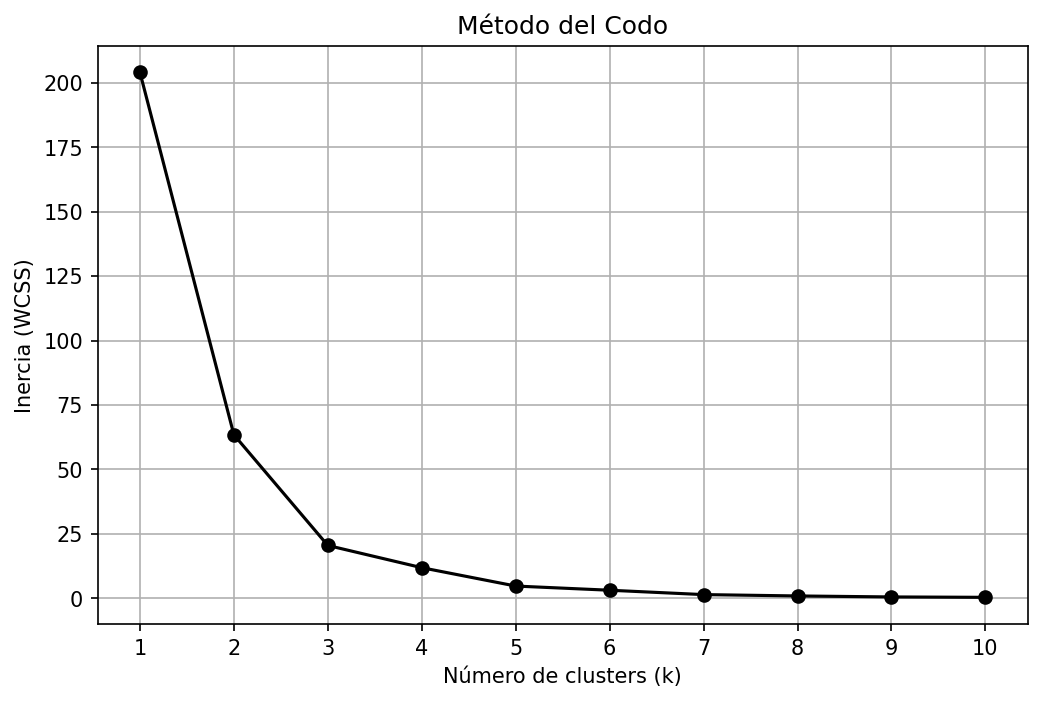

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5),dpi=150)
plt.plot(k_values, inertia, marker='o',color = 'black')
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [63]:
k = 3
km = KMeans(n_clusters=k, random_state=42)
clusters = km.fit_predict(X_scaled)

X['Cluster'] = clusters

In [64]:
X['Cluster'].value_counts().sort_index()

Cluster
0    8
1    2
2    7
Name: count, dtype: int64

In [69]:
X.head()

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,Cluster
Municipio,,,,,,,,,,,,,
Azcapotzalco,8.439703,8.344156,9.243970,8.504638,8.915584,8.258813,7.965677,8.162338,8.170686,8.587199,8.314471,7.723562,0
Benito Juárez,13.519481,13.685529,14.668831,13.774583,14.655844,14.223562,13.410019,13.761596,12.785714,14.449907,13.422078,13.291280,2
Coyoacán,11.571429,11.858998,13.481447,12.223562,12.775510,12.337662,11.506494,11.956401,11.548237,12.124304,11.741187,10.820037,2
Cuajimalpa de Morelos,2.744898,2.767161,3.109462,2.724490,2.923006,2.991651,2.719852,2.805195,2.746753,2.868275,2.739332,2.562152,0
Cuauhtémoc,25.537106,25.219852,28.846939,26.650278,28.352505,27.882189,26.102041,26.621521,25.270872,27.162338,25.746753,24.506494,1


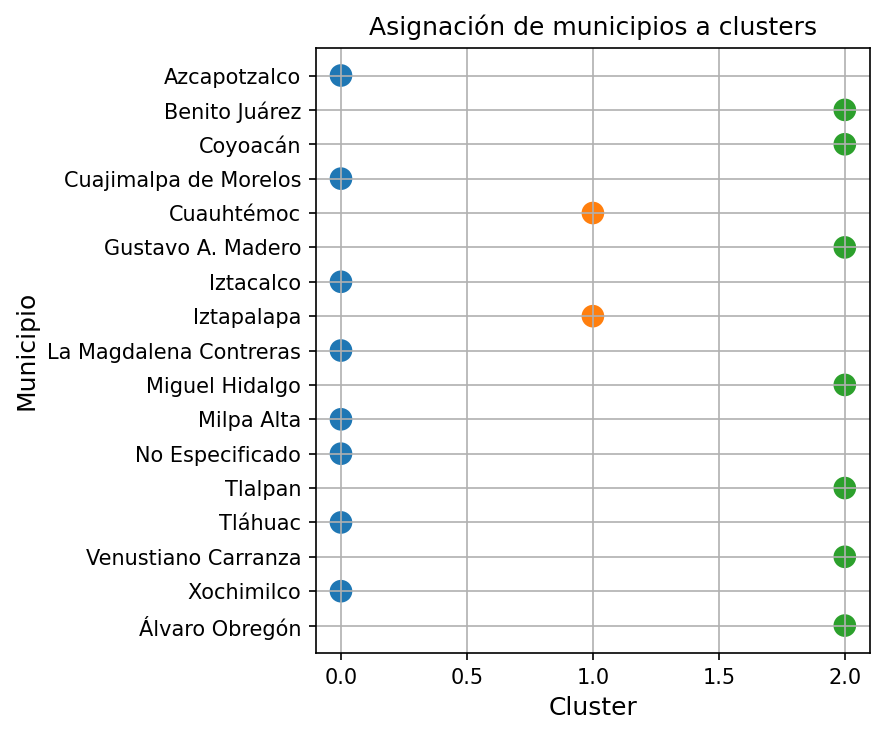

In [95]:
X_vis = X.reset_index().rename(columns={'index': 'Municipio'})

plt.figure(figsize=(6,5),dpi = 150)
sns.scatterplot(data=X_vis, x='Cluster', y='Municipio',
    hue='Cluster', palette='tab10', s=140, legend=False)

plt.title('Asignación de municipios a clusters',fontsize=12)
plt.xlabel('Cluster',fontsize=12)
plt.ylabel('Municipio',fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

- Cluster 0 (baja incidencia): Azcapotzalco, Cuajimalpa de Morelos, Iztacalco, La Magdalena Contreras, Milpa Alta, No Especificado, Tláhuac, Xochimilco, Álvaro Obregón

- Cluster 1 (incidencia alta): Cuauhtémoc, Iztapalapa

- Cluster 2 (incidencia media): Benito Juárez, Coyoacán, Gustavo A. Madero, Miguel Hidalgo, Tlalpan, Venustiano Carranza



In [65]:
# Centros de cluster (patrones promedio)

centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(
    centers,
    columns=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'],
    index=[f'Cluster {i}' for i in range(k)]
)
centers_df

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Cluster 0,4.339054,4.475533,5.052876,4.630566,4.856911,4.688428,4.217069,4.315863,4.270988,4.481447,4.310297,3.984230
Cluster 1,25.287570,25.330241,28.549629,26.257885,27.750464,27.264842,25.395640,25.962430,24.837199,26.553803,24.893321,23.743506
Cluster 2,12.090777,12.216274,13.623377,12.488338,13.148688,12.833422,11.982507,12.223695,11.805327,12.648953,11.862179,11.287437


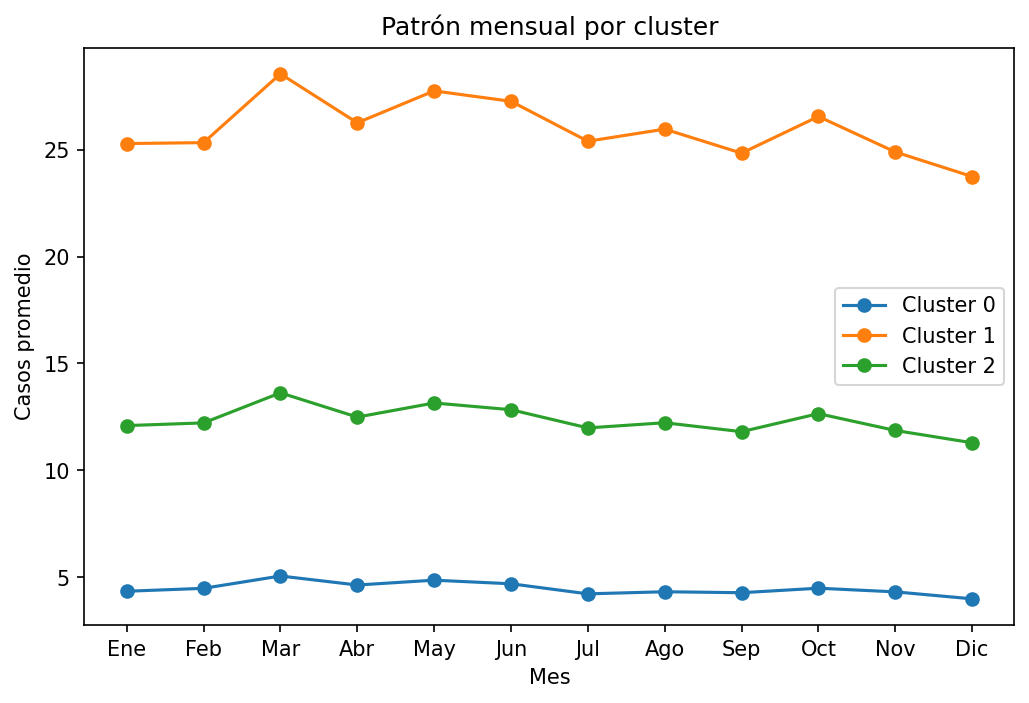

In [67]:
plt.figure(figsize=(8,5),dpi=150)
for i in range(k):
    plt.plot(
        range(1,13),
        centers_df.loc[f'Cluster {i}'],
        marker='o',
        label=f'Cluster {i}'
    )
plt.xticks(range(1,13), centers_df.columns)
plt.xlabel('Mes')
plt.ylabel('Casos promedio')
plt.title('Patrón mensual por cluster')
plt.legend()
plt.show()

| Cluster         | Nivel general de incidencia              | Patrón estacional destacado                                                               | Interpretación típica                                                                                                        |
| --------------- | ---------------------------------------- | ----------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **0 (azul)**    | **Bajo** (≈4–5 casos/mes de promedio)    | – Pico pequeño en marzo–mayo (\~5 casos).<br>– Valle en julio–septiembre (\~4 casos).     | Municipios con muy baja incidencia, prácticamente constante todo el año.                                                     |
| **1 (naranja)** | **Alto** (≈25–28 casos/mes de promedio)  | – Máximo en marzo (\~28–29 casos).<br>– Descenso gradual hacia diciembre (\~23 casos).    | Municipios con alta incidencia y marcada estacionalidad primaveral (posible vínculo con factores climáticos o de movilidad). |
| **2 (verde)**   | **Medio** (≈12–14 casos/mes de promedio) | – Pico moderado en marzo (\~13.5 casos).<br>– Valles en julio–septiembre (\~11–12 casos). | Municipios de incidencia intermedia, que siguen el mismo ciclo anual pero a menor escala que el Cluster 1.                   |


### Posibles usos de estos clusters

#### Priorización de recursos
- Cluster 1: concentrar operativos de seguridad en primavera y otoño.
- Cluster 0: mantener vigilancia básica, pues la incidencia es baja.

#### Diseño de campañas
- Ajustar mensajes preventivos antes del pico de marzo en los municipios de Cluster 1 y 2.

#### Modelado predictivo
- Entrenar modelos de pronóstico específicos por cluster (ya que las dinámicas escalares y estacionales difieren).

#### Análisis espacial
- Mapear geográficamente estos clusters para ver si hay patrones territoriales (p. ej. zonas centrales vs. periféricas).

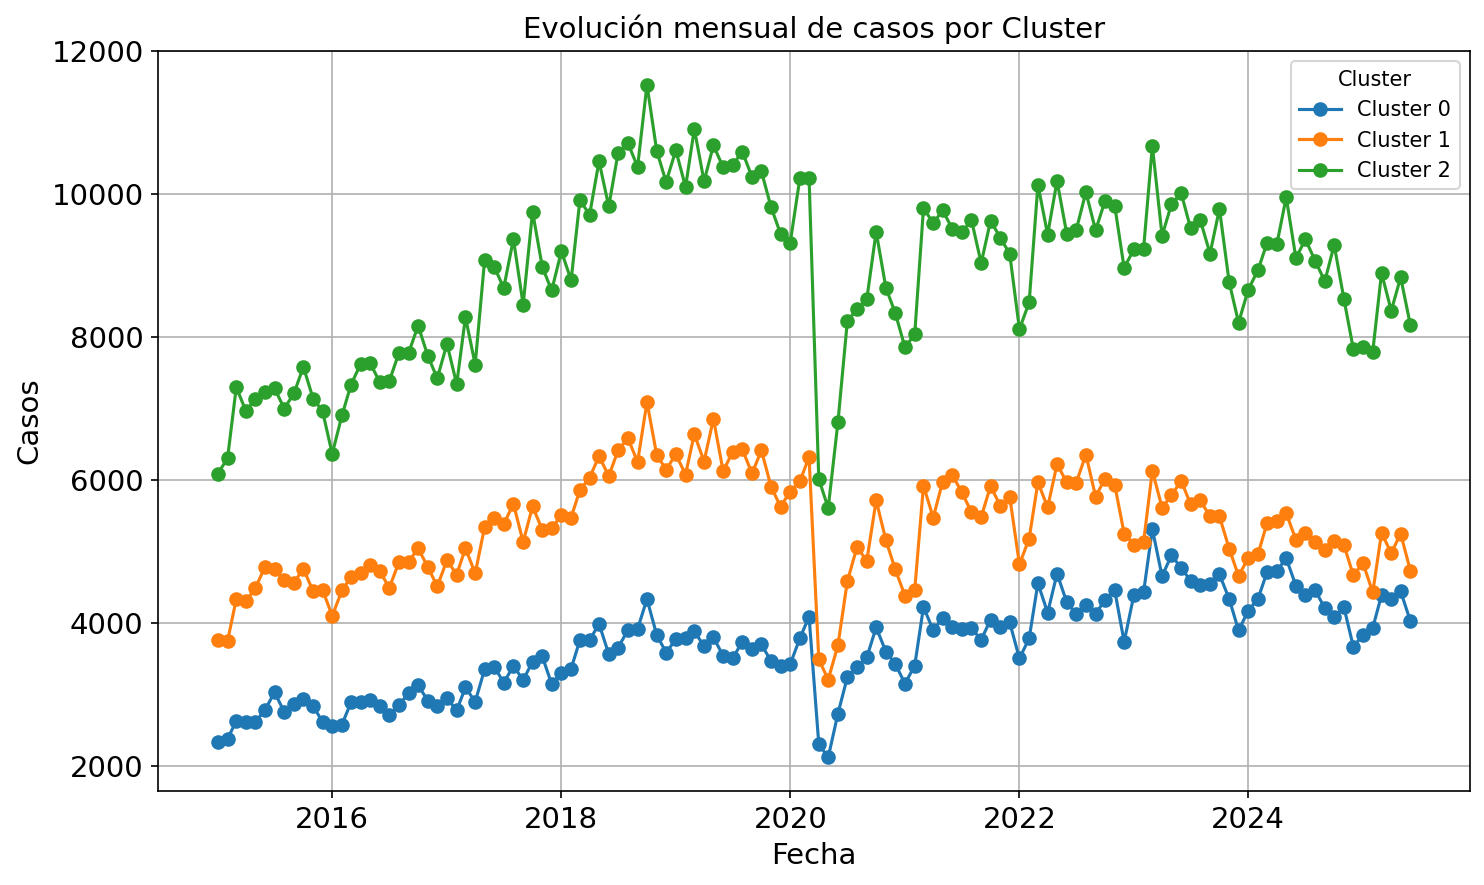

In [91]:
df_ts = (df.reset_index(drop=True).merge(X['Cluster'].rename('Cluster'),
        left_on='Municipio', right_index=True, how='left'))

df_cluster_ts = (df_ts.groupby(['Cluster','Fecha'])['Casos'].sum().reset_index())


df_pivot = (df_cluster_ts.pivot(index='Fecha', columns='Cluster', values='Casos').sort_index())

df_pivot = df_pivot['2015-01':'2025-06']

plt.figure(figsize=(10,6),dpi =150)
for cluster_id in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[cluster_id],
        marker='o', label=f'Cluster {cluster_id}')

plt.title('Evolución mensual de casos por Cluster',fontsize=14)
plt.xlabel('Fecha',fontsize=14)
plt.ylabel('Casos',fontsize=14)
plt.legend(title='Cluster')
plt.tick_params(labelsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

Puedes buscar un modelo para predecir cada serie temporal (o comparar varios modelos para encontrar el mejor)